# Devoir 2 : Prédiction de propriétés moléculaires par réseaux de neurones
(Prediction of molecular properties using neural networks)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/mlbook/blob/main/exercises/devoir2_starter.ipynb)

## Introduction

**Session** : Hiver 2026
**Date de remise** : 7 avril 2026
**Travail en équipe** : groupes de 2-3 étudiants
**Évaluation** : cahier Colab (75%), dérivations manuscrites (25%)

### 1. Objectif

Dans ce devoir, vous prédirez la température critique $T_c$ d'une molécule à partir de sa représentation SMILES. Le but est de comparer quatre approches dans un régime de données limitées :

1. caractéristiques fixes + MLP,
2. modèle séquentiel (LSTM) entraîné à partir de zéro,
3. transformeur entraîné à partir de zéro,
4. représentations pré-entraînées avec SMI-TED.

La question centrale est la suivante : sur un jeu de données modeste, est-ce que des modèles plus expressifs suffisent, ou est-ce que des représentations pré-entraînées sont plus utiles ?

### 2. Jeu de données

Vous utiliserez le fichier `chedl_thermo_properties.csv` disponible dans le dépôt [refgen](https://github.com/ddidacus/refgen/tree/main/data). Le fichier contient environ 24 600 molécules avec leur chaîne SMILES et plusieurs propriétés thermodynamiques. La propriété cible pour toutes les équipes est la **température critique** $T_c$ (en kelvins), disponible pour environ 13 100 molécules. Après filtrage des valeurs non manquantes pour $T_c$, vous effectuerez une séparation entraînement/validation 80/20 avec la graine aléatoire fournie dans le cahier de départ.

### 3. Livrables et consignes générales

Vous remettez sur Studium :

1. un **cahier Colab**,
2. un **PDF scanné** contenant les dérivations manuscrites.

Il n'y a pas de rapport écrit.

Le cahier doit s'exécuter du début à la fin sans erreur. Pour **chaque modèle entraîné**, vous devez fournir : les courbes de perte d'entraînement et de validation, la MSE de validation, le $R^2$ de validation, et l'écart entraînement-validation. À trois endroits du devoir, marqués $\square$, vous devez écrire une **prédiction** dans une cellule Markdown *avant* d'exécuter le code correspondant. L'utilisation d'outils d'IA est permise. Vous pouvez utiliser PyTorch et ses modules intégrés (`nn.Linear`, `nn.LSTM`, `nn.TransformerEncoder`, etc.). Il n'est pas demandé de réimplémenter ces composants.

*English translation:*

**Session**: Winter 2026
**Due date**: April 7, 2026
**Teamwork**: groups of 2-3 students
**Evaluation**: Colab notebook (75%), handwritten derivations (25%)

### 1. Objective

In this assignment, you will predict the critical temperature $T_c$ of a molecule from its SMILES representation. The goal is to compare four approaches in a limited-data regime:

1. fixed features + MLP,
2. sequential model (LSTM) trained from scratch,
3. transformer trained from scratch,
4. pre-trained representations with SMI-TED.

The central question is: on a modest dataset, are more expressive models sufficient, or are pre-trained representations more useful?

### 2. Dataset

You will use the file `chedl_thermo_properties.csv` available in the [refgen](https://github.com/ddidacus/refgen/tree/main/data) repository. The file contains approximately 24,600 molecules with their SMILES string and several thermodynamic properties. The target property for all teams is the **critical temperature** $T_c$ (in kelvins), available for approximately 13,100 molecules. After filtering out missing values for $T_c$, you will perform an 80/20 train/validation split using the random seed provided in the starter notebook.

### 3. Deliverables and general instructions

You will submit on Studium:

1. a **Colab notebook**,
2. a **scanned PDF** containing the handwritten derivations.

There is no written report.

The notebook must run from start to finish without errors. For **each trained model**, you must provide: training and validation loss curves, validation MSE, validation $R^2$, and the train-validation gap. At three points in the assignment, marked $\square$, you must write a **prediction** in a Markdown cell *before* running the corresponding code. The use of AI tools is permitted. You may use PyTorch and its built-in modules (`nn.Linear`, `nn.LSTM`, `nn.TransformerEncoder`, etc.). You are not required to reimplement these components.

In [1]:
%pip install -q rdkit-pypi torch numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# === CONFIGURATION ===
PROPRIETE = "Tc"  # Température critique (K) — même propriété pour toutes les équipes
SEED = 42
MEMBRES = ["Travis"]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://raw.githubusercontent.com/ddidacus/refgen/main/data/chedl_thermo_properties.csv"
df_raw = pd.read_csv(URL)

df = df_raw[df_raw[PROPRIETE].notna() & df_raw["SMILES"].notna()].copy()
df = df[["SMILES", PROPRIETE]].reset_index(drop=True)
df.columns = ["smiles", "target"]

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

print(f"Propriété : {PROPRIETE}")
print(f"Entraînement : {len(train_df)}, Validation : {len(val_df)}")
print("\nStatistiques :")
print(df["target"].describe())

Propriété : Tc
Entraînement : 10504, Validation : 2627

Statistiques :
count    13131.000000
mean       701.367624
std        728.866756
min          0.000000
25%        564.495000
50%        636.040000
75%        718.860000
max      21482.800000
Name: target, dtype: float64


/var/folders/29/r99kczp91990b27g8cgkfymh0000gn/T/ipykernel_50033/1871537947.py:7: DtypeWarning: Columns (0,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(URL)


<details>
<summary>Head lines from <code>chedl_thermo_properties.csv</code></summary>
<pre>
CAS,Tc,Pc,Vc,Zc,SMILES,Chemical,omega,Tc_error,Pc_error,Vc_error,ID,name,Tt,Pt,Tb,MW,Reference,Tm,Hfs,Hfl,Hfg,S0s,S0l,S0g,Hsub,Hfus,Hvap,AntoineTmin,AntoineTmax,AntoineA,AntoineB,AntoineC
675-62-7,561.7,2525000.0,0.000488,0.2638411890397846,C[Si](Cl)(Cl)CCC(F)(F)F,,,,,,,,,,,,,,,,,,,,,,,,,,,
2897-60-1,698.7,1598000.0,0.000865,0.2379402722268626,CCO[Si](C)(CCCOCC1CO1)OCC,,,,,,,,,,,,,,,,,,,,,,,,,,,
7351-61-3,708.1,2113000.0,0.000664,0.2383080960885552,CC(=C)C(=O)OCCC[Si](Cl)(Cl)Cl,,,,,,,,,,,,,,,,,,,,,,,,,,,
2530-83-8,701.4,1812000.0,0.000732,0.2274412993598391,CO[Si](CCCOCC1CO1)(OC)OC,,,,,,,,,,,,,,,,,,,,,,,,,,,
</pre>
</details>

<details>
<summary>Column names and data types</summary>
<pre>
CAS              object   — CAS registry number (identifier)
Tc               float64  — Critical temperature (K)
Pc               float64  — Critical pressure (Pa)
Vc               float64  — Critical volume (m³/mol)
Zc               float64  — Critical compressibility factor
SMILES           object   — SMILES molecular representation
Chemical         object   — Chemical name
omega            float64  — Acentric factor
Tc_error         float64  — Tc measurement error
Pc_error         float64  — Pc measurement error
Vc_error         float64  — Vc measurement error
ID               float64  — Identifier
name             object   — Compound name
Tt               float64  — Triple point temperature (K)
Pt               float64  — Triple point pressure (Pa)
Tb               float64  — Boiling point (K)
MW               float64  — Molecular weight (g/mol)
Reference        object   — Data source reference
Tm               float64  — Melting point (K)
Hfs              float64  — Std. enthalpy of formation, solid (J/mol)
Hfl              float64  — Std. enthalpy of formation, liquid (J/mol)
Hfg              float64  — Std. enthalpy of formation, gas (J/mol)
S0s              float64  — Std. entropy, solid (J/mol·K)
S0l              float64  — Std. entropy, liquid (J/mol·K)
S0g              float64  — Std. entropy, gas (J/mol·K)
Hsub             float64  — Enthalpy of sublimation (J/mol)
Hfus             float64  — Enthalpy of fusion (J/mol)
Hvap             float64  — Enthalpy of vaporization (J/mol)
AntoineTmin      float64  — Antoine equation min temperature (K)
AntoineTmax      float64  — Antoine equation max temperature (K)
AntoineA         float64  — Antoine coefficient A
AntoineB         float64  — Antoine coefficient B
AntoineC         float64  — Antoine coefficient C
</pre>
</details>

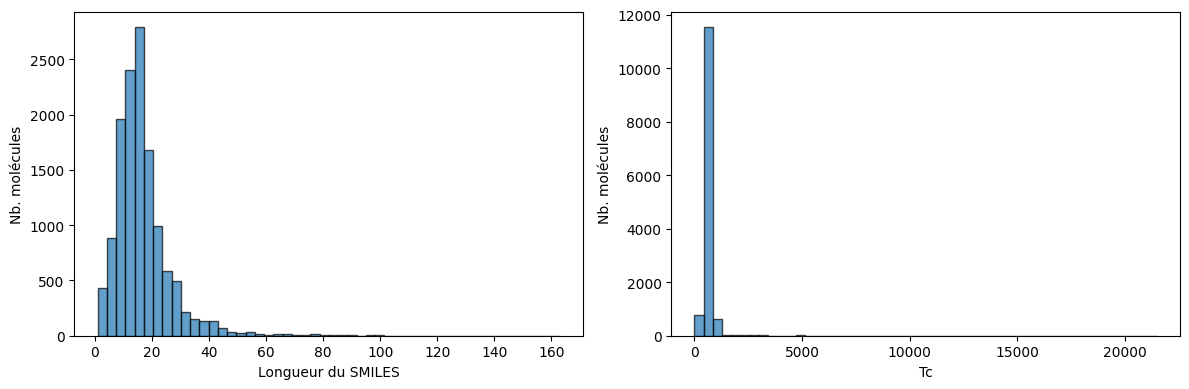

Vocabulaire (60 caractères) : #()+-./123457=@ABCDEFGHIKLMNOPRSTUVWXYZ[\]abcdefghilmnorstuy
Longueur : min=1, max=163, moy=17


In [4]:
smiles_lengths = [len(s) for s in df["smiles"]]
unique_chars = sorted(set("".join(df["smiles"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(smiles_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Longueur du SMILES")
axes[0].set_ylabel("Nb. molécules")
axes[1].hist(df["target"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel(PROPRIETE) # sample label property
axes[1].set_ylabel("Nb. molécules")
plt.tight_layout()
plt.show()

print(f"Vocabulaire ({len(unique_chars)} caractères) : {''.join(unique_chars)}")
print(f"Longueur : min={min(smiles_lengths)}, max={max(smiles_lengths)}, moy={np.mean(smiles_lengths):.0f}")

In [5]:
def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")

## Partie 1 — MLP et entraînement (Ch. 7-8)

### 1.1 Caractéristiques fixes et MLP

Chaque chaîne SMILES encode la structure d'une molécule sous forme de texte. Par exemple, `CCO` représente l'éthanol et `c1ccccc1` le benzène. Vous n'avez pas besoin de connaissances en chimie pour ce devoir : il suffit de traiter les SMILES comme des chaînes de caractères. La fonction `smiles_to_features` ci-dessous convertit une chaîne SMILES en un vecteur numérique de longueur fixe. Cette représentation compte la fréquence de chaque caractère du vocabulaire SMILES (par exemple combien de fois `C`, `O`, `(`, `)`, `=` apparaissent), ajoute la longueur totale de la chaîne, et inclut quelques indicatrices binaires. Entraînez un MLP à 2 couches cachées sur ces caractéristiques pour prédire $T_c$.

$\square$ **Prédiction 1** : Avant l'entraînement, écrivez si vous pensez que ce modèle va surapprendre, et justifiez brièvement.

### 1.2 Comparaison d'optimiseurs

Entraînez le **même MLP** avec trois optimiseurs : SGD, SGD avec momentum, et Adam. Gardez la même architecture et les mêmes hyperparamètres, à l'exception de l'optimiseur. Tracez les trois courbes de perte de validation sur un même graphique.

$\square$ **Prédiction 2** : Avant l'expérience, écrivez quel optimiseur convergera le plus vite, et pourquoi.

### 1.3 Régularisation et stabilisation du gradient

Partez d'un MLP profond à 5 couches cachées et comparez les quatre configurations suivantes :

| \# | Configuration |
|---|---|
| 1 | Sigmoid + initialisation par défaut |
| 2 | ReLU + initialisation He |
| 3 | Configuration 2 + BatchNorm |
| 4 | Configuration 3 + Dropout ($p=0.3$) |

Pour chaque configuration, rapportez la MSE de validation finale, la norme moyenne du gradient $\ell_2$ à la première couche cachée (moyennée sur les mini-lots du dernier epoch), et l'écart entraînement-validation.

### Dérivations manuscrites (Partie 1)

Sur papier :

1. Dérivez les règles VJP pour l'opération $\text{matmul}(W, x)$, c'est-à-dire $\partial L / \partial W$ et $\partial L / \partial x$.
2. Dessinez le graphe de calcul complet du MLP à 2 couches, de l'entrée jusqu'à la perte, et annotez les VJP.

*English translation:*

### 1.1 Fixed features and MLP

Each SMILES string encodes the structure of a molecule as text. For example, `CCO` represents ethanol and `c1ccccc1` benzene. You do not need any chemistry knowledge for this assignment: just treat SMILES as character strings. The `smiles_to_features` function below converts a SMILES string into a fixed-length numerical vector. This representation counts the frequency of each character in the SMILES vocabulary (e.g. how many times `C`, `O`, `(`, `)`, `=` appear), adds the total string length, and includes a few binary indicators. Train a 2-hidden-layer MLP on these features to predict $T_c$.

$\square$ **Prediction 1**: Before training, write whether you think this model will overfit, and briefly justify.

### 1.2 Optimizer comparison

Train the **same MLP** with three optimizers: SGD, SGD with momentum, and Adam. Keep the same architecture and hyperparameters, except for the optimizer. Plot the three validation loss curves on a single graph.

$\square$ **Prediction 2**: Before the experiment, write which optimizer will converge fastest, and why.

### 1.3 Regularization and gradient stabilization

Start from a deep MLP with 5 hidden layers and compare the following four configurations:

| \# | Configuration |
|---|---|
| 1 | Sigmoid + default initialization |
| 2 | ReLU + He initialization |
| 3 | Configuration 2 + BatchNorm |
| 4 | Configuration 3 + Dropout ($p=0.3$) |

For each configuration, report the final validation MSE, the mean $\ell_2$ gradient norm at the first hidden layer (averaged over mini-batches of the last epoch), and the train-validation gap.

### Handwritten derivations (Part 1)

On paper:

1. Derive the VJP rules for the $\text{matmul}(W, x)$ operation, i.e. $\partial L / \partial W$ and $\partial L / \partial x$.
2. Draw the complete computation graph of the 2-layer MLP, from input to loss, and annotate the VJPs.

In [6]:
# Vocabulaire : tous les caractères uniques présents dans les SMILES du jeu de données
vocab = sorted(set("".join(df["smiles"])))
char_to_idx = {c: i for i, c in enumerate(vocab)}


def smiles_to_features(smiles: str) -> np.ndarray:
    """Convertit une chaîne SMILES en vecteur de caractéristiques de longueur fixe.

    Le vecteur contient :
      - la fréquence de chaque caractère du vocabulaire (taille = len(vocab)),
      - la longueur de la chaîne SMILES.
    """
    counts = np.zeros(len(vocab), dtype=np.float32)
    for c in smiles:
        if c in char_to_idx:
            counts[char_to_idx[c]] += 1
    length = np.array([len(smiles)], dtype=np.float32)
    return np.concatenate([counts, length])


# Construire les matrices de caractéristiques
X_train = np.stack([smiles_to_features(s) for s in train_df["smiles"]])
X_val = np.stack([smiles_to_features(s) for s in val_df["smiles"]])
y_train = train_df["target"].values.astype(np.float32)
y_val = val_df["target"].values.astype(np.float32)

print(f"X_train : {X_train.shape}  (nb. molécules × nb. caractéristiques)")
print(f"X_val   : {X_val.shape}")
print(f"Caractéristiques par molécule : {X_train.shape[1]} ({len(vocab)} fréquences de caractères + 1 longueur)")

X_train : (10504, 61)  (nb. molécules × nb. caractéristiques)
X_val   : (2627, 61)
Caractéristiques par molécule : 61 (60 fréquences de caractères + 1 longueur)


<details>
<summary><code>X_train</code> columns (61 features)</summary>
<pre>
Index  Name          Type     Description
-----  ----          ----     -----------
0      freq_#        float32  Frequency of '#' (triple bond)
1      freq_(        float32  Frequency of '(' (branch open)
2      freq_)        float32  Frequency of ')' (branch close)
3      freq_+        float32  Frequency of '+' (positive charge)
4      freq_-        float32  Frequency of '-' (negative charge / single bond)
5      freq_.        float32  Frequency of '.' (disconnected structure)
6      freq_/        float32  Frequency of '/' (cis/trans bond)
7      freq_1        float32  Frequency of '1' (ring closure)
8      freq_2        float32  Frequency of '2' (ring closure)
9      freq_3        float32  Frequency of '3' (ring closure)
10     freq_4        float32  Frequency of '4' (ring closure)
11     freq_5        float32  Frequency of '5' (ring closure)
12     freq_7        float32  Frequency of '7' (ring closure)
13     freq_=        float32  Frequency of '=' (double bond)
14     freq_@        float32  Frequency of '@' (chirality)
15     freq_A        float32  Frequency of 'A' (e.g. Al, As, Ag)
16     freq_B        float32  Frequency of 'B' (boron)
17     freq_C        float32  Frequency of 'C' (carbon)
18     freq_D        float32  Frequency of 'D' (deuterium)
19     freq_E        float32  Frequency of 'E' (element symbol part)
20     freq_F        float32  Frequency of 'F' (fluorine)
21     freq_G        float32  Frequency of 'G' (element symbol part)
22     freq_H        float32  Frequency of 'H' (hydrogen)
23     freq_I        float32  Frequency of 'I' (iodine)
24     freq_K        float32  Frequency of 'K' (potassium)
25     freq_L        float32  Frequency of 'L' (element symbol part)
26     freq_M        float32  Frequency of 'M' (element symbol part)
27     freq_N        float32  Frequency of 'N' (nitrogen)
28     freq_O        float32  Frequency of 'O' (oxygen)
29     freq_P        float32  Frequency of 'P' (phosphorus)
30     freq_R        float32  Frequency of 'R' (element symbol part)
31     freq_S        float32  Frequency of 'S' (sulfur)
32     freq_T        float32  Frequency of 'T' (element symbol part)
33     freq_U        float32  Frequency of 'U' (element symbol part)
34     freq_V        float32  Frequency of 'V' (element symbol part)
35     freq_W        float32  Frequency of 'W' (element symbol part)
36     freq_X        float32  Frequency of 'X' (element symbol part)
37     freq_Y        float32  Frequency of 'Y' (element symbol part)
38     freq_Z        float32  Frequency of 'Z' (element symbol part)
39     freq_[        float32  Frequency of '[' (atom bracket open)
40     freq_\        float32  Frequency of '\' (cis/trans bond)
41     freq_]        float32  Frequency of ']' (atom bracket close)
42     freq_a        float32  Frequency of 'a' (aromatic, e.g. [nH])
43     freq_b        float32  Frequency of 'b' (aromatic boron)
44     freq_c        float32  Frequency of 'c' (aromatic carbon)
45     freq_d        float32  Frequency of 'd' (element symbol part)
46     freq_e        float32  Frequency of 'e' (e.g. Se, Te)
47     freq_f        float32  Frequency of 'f' (element symbol part)
48     freq_g        float32  Frequency of 'g' (element symbol part)
49     freq_h        float32  Frequency of 'h' (element symbol part)
50     freq_i        float32  Frequency of 'i' (element symbol part)
51     freq_l        float32  Frequency of 'l' (e.g. Cl, Al)
52     freq_m        float32  Frequency of 'm' (element symbol part)
53     freq_n        float32  Frequency of 'n' (aromatic nitrogen)
54     freq_o        float32  Frequency of 'o' (aromatic oxygen)
55     freq_r        float32  Frequency of 'r' (element symbol part)
56     freq_s        float32  Frequency of 's' (aromatic sulfur)
57     freq_t        float32  Frequency of 't' (element symbol part)
58     freq_u        float32  Frequency of 'u' (element symbol part)
59     freq_y        float32  Frequency of 'y' (element symbol part)
60     length        float32  Total length of the SMILES string
</pre>
</details>

---
## Partie 2 — Modèles séquentiels et attention (Ch. 9-10)

### 2.1 LSTM

Implémentez en PyTorch le pipeline suivant :

```
SMILES → plongement de caractères → LSTM → état final → couche linéaire → prédiction
```

Utilisez une gestion correcte des séquences de longueurs variables. Si vous utilisez du remplissage (*padding*), vos agrégations et vos masques doivent ignorer les positions de remplissage.

$\square$ **Prédiction 3** : Avant l'entraînement, écrivez si vous pensez que le LSTM fera mieux que le MLP en validation, et justifiez brièvement.

### 2.2 Calcul d'attention à la main (dérivation manuscrite)

Considérez le SMILES `CCO` avec $d_{\text{model}} = 4$ et $d_k = 2$. Les matrices de projection sont :

$$W_Q = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \\ 0 & 0 \end{pmatrix}, \quad W_K = \begin{pmatrix} 0 & 1 \\ 1 & 0 \\ 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad W_V = \begin{pmatrix} 1 & 1 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}$$

Les plongements sont des vecteurs colonnes, et la convention est $q_i = W_Q^\top e_i$, $k_i = W_K^\top e_i$, $v_i = W_V^\top e_i$. De manière équivalente, si l'on empile les plongements comme lignes d'une matrice $E \in \mathbb{R}^{3 \times 4}$, alors $Q = E\,W_Q$, $K = E\,W_K$, $V = E\,W_V$. Les trois plongements sont :

$$e_1 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_2 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_3 = e_O = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 1 \end{pmatrix}$$

Calculez à la main : (1) les matrices $Q$, $K$ et $V$, (2) les scores d'attention $QK^\top / \sqrt{d_k}$, (3) les poids après softmax, (4) la sortie finale de la couche d'attention.

### 2.3 Transformeur encodeur

Implémentez un transformeur encodeur pour la prédiction de $T_c$ avec : un plongement caractère par caractère, un encodage positionnel sinusoïdal, 2 couches de transformeur, une agrégation par moyenne sur les positions non remplies, et une couche linéaire finale.

### 2.4 Tableau comparatif

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformeur | | | | |

*English translation:*

### 2.1 LSTM

Implement the following pipeline in PyTorch:

```
SMILES → character embedding → LSTM → final state → linear layer → prediction
```

Use correct handling of variable-length sequences. If you use padding, your aggregations and masks must ignore the padding positions.

$\square$ **Prediction 3**: Before training, write whether you think the LSTM will perform better than the MLP on validation, and briefly justify.

### 2.2 Computing attention by hand (handwritten derivation)

Consider the SMILES `CCO` with $d_{\text{model}} = 4$ and $d_k = 2$. The projection matrices are:

$$W_Q = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \\ 0 & 0 \end{pmatrix}, \quad W_K = \begin{pmatrix} 0 & 1 \\ 1 & 0 \\ 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad W_V = \begin{pmatrix} 1 & 1 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}$$

The embeddings are column vectors, and the convention is $q_i = W_Q^\top e_i$, $k_i = W_K^\top e_i$, $v_i = W_V^\top e_i$. Equivalently, if we stack the embeddings as rows of a matrix $E \in \mathbb{R}^{3 \times 4}$, then $Q = E\,W_Q$, $K = E\,W_K$, $V = E\,W_V$. The three embeddings are:

$$e_1 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_2 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_3 = e_O = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 1 \end{pmatrix}$$

Compute by hand: (1) the matrices $Q$, $K$ and $V$, (2) the attention scores $QK^\top / \sqrt{d_k}$, (3) the weights after softmax, (4) the final output of the attention layer.

### 2.3 Transformer encoder

Implement a transformer encoder for predicting $T_c$ with: character-by-character embedding, sinusoidal positional encoding, 2 transformer layers, mean aggregation over non-padded positions, and a final linear layer.

### 2.4 Comparison table

| Model | Val MSE | Val $R^2$ | Nb. parameters | Train-val gap |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformer | | | | |

---
## Partie 3 — Apprentissage par transfert (Ch. 10 + synthèse)

### 3.1 Plongements SMI-TED

Chargez le modèle pré-entraîné [SMI-TED](https://huggingface.co/ibm-research/materials.smi-ted) à partir du code fourni ci-dessous, puis extrayez un plongement de dimension 768 pour chaque molécule. Visualisez ces plongements en 2D en utilisant `sklearn.decomposition.PCA` ou `sklearn.manifold.TSNE`, colorés par la valeur de $T_c$.

### 3.2 Sonde linéaire

Gelez SMI-TED et entraînez uniquement une couche linéaire sur les plongements extraits pour prédire $T_c$.

### 3.3 Courbe d'efficacité en échantillons

Tracez sur un même graphique la MSE de validation en fonction de la taille d'entraînement (10%, 25%, 50%, 100%) pour les quatre modèles : MLP, LSTM, transformeur, SMI-TED + sonde linéaire. Pour cette section, réutilisez la meilleure configuration choisie à 100% des données, gardez un même budget d'époques pour tous les sous-ensembles, et ne faites pas de nouvel ajustement d'hyperparamètres. Cette figure est la **figure centrale** du devoir.

Complétez aussi le tableau final, à 100% des données :

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformeur | | | | |
| SMI-TED + sonde linéaire | | | | |

*English translation:*

### 3.1 SMI-TED embeddings

Load the pre-trained [SMI-TED](https://huggingface.co/ibm-research/materials.smi-ted) model from the code provided below, then extract a 768-dimensional embedding for each molecule. Visualize these embeddings in 2D using `sklearn.decomposition.PCA` or `sklearn.manifold.TSNE`, colored by the value of $T_c$.

### 3.2 Linear probe

Freeze SMI-TED and train only a linear layer on the extracted embeddings to predict $T_c$.

### 3.3 Sample efficiency curve

Plot on a single graph the validation MSE as a function of training size (10%, 25%, 50%, 100%) for all four models: MLP, LSTM, transformer, SMI-TED + linear probe. For this section, reuse the best configuration chosen at 100% of the data, keep the same epoch budget for all subsets, and do not perform new hyperparameter tuning. This figure is the **central figure** of the assignment.

Also complete the final table, at 100% of the data:

| Model | Val MSE | Val $R^2$ | Nb. parameters | Train-val gap |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformer | | | | |
| SMI-TED + linear probe | | | | |

### Chargement de SMI-TED

SMI-TED est un modèle de fondation pré-entraîné sur 91 millions de molécules.

In [7]:
import os, sys, torch

# Cloner le dépôt et installer les dépendances
!git clone --depth 1 https://github.com/IBM/materials.git /tmp/materials 2>/dev/null || true
%pip install -q pytorch-fast-transformers torch-optimizer huggingface_hub

# Télécharger les poids
SMI_TED_DIR = "/tmp/materials/models/smi_ted/inference/smi_ted_light"
if not os.path.exists(os.path.join(SMI_TED_DIR, "smi_ted_light.pt")):
    from huggingface_hub import hf_hub_download
    hf_hub_download(repo_id="ibm-research/materials.smi-ted",
                    filename="smi_ted_light.pt", local_dir=SMI_TED_DIR)

# Charger le modèle
sys.path.insert(0, "/tmp/materials/models/smi_ted/inference")
from load import load_smi_ted

smi_ted = load_smi_ted(folder=SMI_TED_DIR, ckpt_filename="smi_ted_light.pt")
smi_ted.eval()

# Test rapide
with torch.no_grad():
    test_emb = smi_ted.encode(["CCO", "c1ccccc1"], return_torch=True)
print(f"Plongements : {test_emb.shape}")  # (2, 768)

OSError: [Errno 5] Input/output error

---
## Partie 4 — Évaluation

### Cahier Colab (75%)

| Élément | Points |
|---|---|
| Le cahier s'exécute sans erreur | 5 |
| 1.1 : MLP fonctionnel + courbes d'apprentissage | 10 |
| 1.2 : comparaison des optimiseurs | 5 |
| 1.3 : 4 configurations + tableau de résultats | 10 |
| 2.1 : LSTM fonctionnel + courbes | 10 |
| 2.3 : transformeur fonctionnel + courbes | 10 |
| 2.4 : tableau comparatif rempli | 5 |
| 3.1 : plongements SMI-TED + visualisation 2D | 5 |
| 3.2 : sonde linéaire fonctionnelle + courbes | 5 |
| 3.3 : courbe d'efficacité en échantillons | 5 |
| 3 prédictions présentes en cellules Markdown | 5 |
| **Total** | **75** |

### Dérivations manuscrites (25%)

| Élément | Points |
|---|---|
| VJP de $\text{matmul}(W, x)$ | 8 |
| Graphe de calcul du MLP annoté avec les VJP | 5 |
| Calcul d'attention à la main | 12 |
| **Total** | **25** |

*English translation:*

### Colab notebook (75%)

| Element | Points |
|---|---|
| Notebook runs without errors | 5 |
| 1.1: Working MLP + learning curves | 10 |
| 1.2: Optimizer comparison | 5 |
| 1.3: 4 configurations + results table | 10 |
| 2.1: Working LSTM + curves | 10 |
| 2.3: Working transformer + curves | 10 |
| 2.4: Comparison table filled in | 5 |
| 3.1: SMI-TED embeddings + 2D visualization | 5 |
| 3.2: Working linear probe + curves | 5 |
| 3.3: Sample efficiency curve | 5 |
| 3 predictions present in Markdown cells | 5 |
| **Total** | **75** |

### Handwritten derivations (25%)

| Element | Points |
|---|---|
| VJP of $\text{matmul}(W, x)$ | 8 |
| Computation graph of the MLP annotated with VJPs | 5 |
| Attention computation by hand | 12 |
| **Total** | **25** |